# London House Price Prediction
## Auditable Data Science Pipeline

**Objective:** Predict London property sale prices using property-level and area-level features.

**Methodology:** 4-stage pipeline — data ingestion, EDA, baseline modelling, performance improvement.

**Reproducibility:** All random operations use `random_state=42`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
print("All libraries loaded successfully.")

All libraries loaded successfully.


---
# STAGE 1: Data Ingestion and Quality Assessment

**Objective:** Load both datasets, assess quality, merge, and clean.

**Verification gate:** Merged dataset with documented quality issues and cleaning decisions.

In [2]:
# Load datasets
prices = pd.read_csv('london_house_prices.csv')
areas = pd.read_csv('london_area_features.csv')

print("=== House Prices Dataset ===")
print(f"Shape: {prices.shape}")
print(f"\nColumn names and data types:")
print(prices.dtypes)
print(f"\nFirst 5 rows:")
prices.head()

=== House Prices Dataset ===
Shape: (417561, 12)

Column names and data types:
outcode          object
latitude        float64
longitude       float64
bedrooms        float64
bathrooms       float64
floorAreaSqM    float64
livingRooms     float64
propertyType     object
tenure           object
energyRating     object
rentEstimate    float64
price           float64
dtype: object

First 5 rows:


,outcode,latitude,longitude,bedrooms,bathrooms,floorAreaSqM,livingRooms,propertyType,tenure,energyRating,rentEstimate,price
0,EC4A,51.52,-0.11,1.00,1.00,45.00,1.00,Purpose Built Flat,Leasehold,NaN,2350.00,600000.00
1,EC4A,51.52,-0.11,NaN,NaN,NaN,NaN,Flat/Maisonette,Leasehold,NaN,2350.00,600000.00
2,SW1P,51.50,-0.13,2.00,2.00,71.00,1.00,Flat/Maisonette,Leasehold,C,2950.00,759000.00
3,SE5,51.48,-0.09,1.00,1.00,64.00,1.00,Flat/Maisonette,Leasehold,D,2000.00,388000.00
4,N10,51.59,-0.14,4.00,1.00,137.00,2.00,End Terrace House,Freehold,D,4850.00,1261000.00


In [3]:
print("=== Area Features Dataset ===")
print(f"Shape: {areas.shape}")
print(f"\nColumn names and data types:")
print(areas.dtypes)
print(f"\nFirst 5 rows:")
areas.head()

=== Area Features Dataset ===
Shape: (168, 52)

Column names and data types:
outcode                                object
outcode_lat                           float64
outcode_lon                           float64
n_properties                            int64
crime_anti_social_behaviour             int64
crime_bicycle_theft                     int64
crime_burglary                          int64
crime_criminal_damage_and_arson         int64
crime_drugs                             int64
crime_other_crime                       int64
crime_other_theft                       int64
crime_possession_of_weapons             int64
crime_public_order                      int64
crime_robbery                           int64
crime_shoplifting                       int64
crime_theft_from_the_person             int64
crime_vehicle_crime                     int64
crime_violence_and_sexual_offences      int64
crime_total                             int64
census_denom_total                    float64
cen

,outcode,outcode_lat,outcode_lon,n_properties,crime_anti_social_behaviour,crime_bicycle_theft,crime_burglary,crime_criminal_damage_and_arson,crime_drugs,crime_other_crime,crime_other_theft,crime_possession_of_weapons,crime_public_order,crime_robbery,crime_shoplifting,crime_theft_from_the_person,crime_vehicle_crime,crime_violence_and_sexual_offences,crime_total,census_denom_total,census_employed_total_perc,census_retired_perc,census_unemployed_perc,census_age_16_to_34_perc,census_age_65_plus_perc,census_level4_perc,census_no_qualifications_perc,poi_bakery,poi_bank,poi_bar,poi_bus_station,poi_cafe,poi_clinic,poi_community_centre,poi_conference_centre,poi_coworking_space,poi_disused,poi_doctors,poi_dojo,poi_fast_food,poi_ferry_terminal,poi_leisure_centre,poi_library,poi_office,poi_pub,poi_restaurant,poi_serviced_office,poi_stock_exchange,poi_townhall,poi_university,poi_vehicle_inspection,poi_total
0,E1,51.52,-0.06,2260,3949,386,429,431,699,76,698,54,568,233,142,395,624,2230,10914,745.72,52.45,6.85,4.75,42.31,6.81,42.51,20.22,0,0,5,0,54,0,0,0,0,0,0,0,72,0,0,3,0,20,58,0,0,0,2,0,214
1,E10,51.57,-0.01,3879,2266,99,248,331,386,69,554,39,380,160,217,151,705,1710,7315,770.10,60.34,9.13,4.84,32.29,8.50,42.69,19.14,0,0,11,0,38,0,0,0,1,0,0,0,37,0,0,2,0,11,46,0,0,0,0,0,146
2,E11,51.57,0.02,5177,1340,49,217,219,200,46,404,16,262,101,123,85,472,1031,4565,620.17,62.10,14.33,3.96,27.93,13.10,50.59,14.54,0,0,7,0,35,0,0,0,0,0,0,0,27,0,0,4,0,11,51,0,0,0,0,0,135
3,E12,51.55,0.05,1722,11171,345,1787,2160,1872,444,3287,209,2235,901,1784,1172,3719,11259,42345,804.93,52.08,10.24,4.37,30.00,9.25,38.59,20.98,0,0,5,2,80,0,0,0,0,0,0,0,116,0,0,11,0,35,108,0,0,0,0,0,357
4,E13,51.53,0.03,1553,2336,61,343,441,396,90,684,56,496,189,165,285,719,2186,8447,1906.11,53.32,8.60,5.35,32.56,8.09,35.72,23.67,0,0,3,0,42,0,0,0,0,0,0,0,61,0,0,2,0,9,74,0,0,0,0,0,191


In [4]:
# Missing values report
def missing_report(df, name):
    """Generate a missing values report with count and percentage."""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f"\n=== Missing Values: {name} ===")
    if len(report) == 0:
        print("No missing values.")
    else:
        print(report.to_string())
    return report

prices_missing = missing_report(prices, 'House Prices')
areas_missing = missing_report(areas, 'Area Features')


=== Missing Values: House Prices ===
              Missing Count  Missing %
energyRating          84288      20.19
bathrooms             77755      18.62
livingRooms           60341      14.45
bedrooms              40404       9.68
floorAreaSqM          25066       6.00
tenure                11494       2.75
propertyType           1126       0.27
rentEstimate           1101       0.26

=== Missing Values: Area Features ===
No missing values.


In [5]:
# Price outlier analysis
print("=== Price Distribution Statistics ===")
print(prices['price'].describe())

Q1 = prices['price'].quantile(0.25)
Q3 = prices['price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR
lower_fence = Q1 - 3 * IQR

print(f"\nQ1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Upper fence (Q3 + 3*IQR): {upper_fence:,.0f}")
print(f"Lower fence (Q1 - 3*IQR): {lower_fence:,.0f}")
print(f"\nProperties above upper fence: {(prices['price'] > upper_fence).sum()} ({(prices['price'] > upper_fence).mean()*100:.2f}%)")
print(f"Properties below lower fence: {(prices['price'] < lower_fence).sum()}")
print(f"Price skewness: {prices['price'].skew():.2f}")

=== Price Distribution Statistics ===
count     417561.00
mean      904518.76
std       920291.66
min        89000.00
25%       446000.00
50%       622000.00
75%       984000.00
max     29220000.00
Name: price, dtype: float64

Q1: 446,000
Q3: 984,000
IQR: 538,000
Upper fence (Q3 + 3*IQR): 2,598,000
Lower fence (Q1 - 3*IQR): -1,168,000

Properties above upper fence: 18574 (4.45%)
Properties below lower fence: 0
Price skewness: 5.05


### Decision Block: Price Outlier Strategy

**Analysis:** Prices range from ~89K to ~29.2M. London house prices are genuinely right-skewed — multi-million pound properties in central London are real, not data errors.

| Option | Description | Pros | Cons | Selected? |
|--------|------------|------|------|-----------|
| **A** | Cap at Q3 + 3×IQR | Statistically principled; conservative; preserves genuine luxury properties | Arbitrary threshold; some ultra-luxury properties capped | **Yes** |
| B | Remove all above fixed threshold (e.g. £5M) | Simple | Arbitrary cutoff; loses informative data; £5M not unusual in central London | No |
| C | No outlier handling | Preserves all data | Extreme values inflate RMSE; Linear Regression particularly sensitive | No |

**Verdict:** Option A — the 3×IQR threshold (rather than the standard 1.5×) is conservative enough for London's genuinely skewed market, capping only the most extreme tail values while preserving the natural distribution shape.

In [6]:
# Merge datasets on outcode
prices_outcodes = set(prices['outcode'].dropna().unique())
areas_outcodes = set(areas['outcode'].unique())

print(f"Unique outcodes in prices: {len(prices_outcodes)}")
print(f"Unique outcodes in areas: {len(areas_outcodes)}")
print(f"Overlap: {len(prices_outcodes & areas_outcodes)}")
print(f"In prices but not areas: {len(prices_outcodes - areas_outcodes)}")
print(f"In areas but not prices: {len(areas_outcodes - prices_outcodes)}")

# Left merge to keep all price records
df = prices.merge(areas, on='outcode', how='left')
print(f"\nMerged shape: {df.shape}")
print(f"Rows with area features: {df['crime_total'].notna().sum():,}")
print(f"Rows without area features: {df['crime_total'].isna().sum():,}")

Unique outcodes in prices: 168
Unique outcodes in areas: 168
Overlap: 168
In prices but not areas: 0
In areas but not prices: 0



Merged shape: (417561, 63)


Rows with area features: 417,561
Rows without area features: 0


### Decision Block: Missing Value Handling Strategy

| Option | Description | Pros | Cons | Selected? |
|--------|------------|------|------|-----------|
| **A** | Median imputation (numeric), mode imputation (categorical) | Simple; robust to outliers; preserves all 417K rows; standard for tree-based models | Does not capture inter-feature relationships; may bias distributions slightly | **Yes** |
| B | Drop rows with any missing values | Clean dataset | Would lose ~40–50% of data; massive information loss; likely introduces selection bias | No |
| C | KNN or iterative imputation | Captures feature correlations | Computationally expensive on 417K rows; risk of data leakage if not done within CV folds | No |

**Verdict:** Option A — with 417K rows, median/mode imputation is the pragmatic choice. Tree-based models (Random Forest, XGBoost) are robust to this strategy. The key missing columns have enough non-missing data for reliable median/mode estimates.

In [7]:
# Apply data cleaning

# 1. Cap extreme prices
print("--- Price Outlier Capping ---")
print(f"Before capping: max price = \u00a3{df['price'].max():,.0f}")
n_capped = (df['price'] > upper_fence).sum()
df['price'] = df['price'].clip(upper=upper_fence)
print(f"After capping: max price = \u00a3{df['price'].max():,.0f}")
print(f"Properties capped: {n_capped}")

# 2. Impute missing numeric values with median
print("\n--- Numeric Imputation (Median) ---")
numeric_impute_cols = ['bedrooms', 'bathrooms', 'floorAreaSqM', 'livingRooms', 'rentEstimate']
for col in numeric_impute_cols:
    median_val = df[col].median()
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: imputed {n_missing:,} values with median = {median_val:.1f}")

# 3. Impute missing categorical values with mode
print("\n--- Categorical Imputation (Mode) ---")
for col in ['propertyType', 'tenure', 'energyRating']:
    mode_val = df[col].mode()[0]
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: imputed {n_missing:,} values with mode = '{mode_val}'")

# 4. Consolidate propertyType into 5 clean groups
print("\n--- PropertyType Consolidation ---")
print(f"Original unique values: {df['propertyType'].nunique()}")

property_type_map = {
    'Purpose Built Flat': 'Flat', 'Flat/Maisonette': 'Flat', 'Converted Flat': 'Flat',
    'Mid Terrace House': 'Terraced', 'Terrace Property': 'Terraced',
    'End Terrace House': 'Terraced', 'Terraced': 'Terraced',
    'Mid Terrace Property': 'Terraced', 'End Terrace Property': 'Terraced',
    'Semi-Detached House': 'Semi-Detached', 'Semi-Detached Property': 'Semi-Detached',
    'Semi-Detached Bungalow': 'Semi-Detached',
    'Detached House': 'Detached', 'Detached Property': 'Detached',
    'Detached Bungalow': 'Detached',
}
df['propertyType_clean'] = df['propertyType'].map(property_type_map).fillna('Other')
print(f"Consolidated to {df['propertyType_clean'].nunique()} groups:")
print(df['propertyType_clean'].value_counts())

# 5. Fill area-level NaNs from unmatched outcodes
print("\n--- Area Feature Imputation ---")
area_cols = [c for c in areas.columns if c != 'outcode']
area_missing_total = 0
for col in area_cols:
    if col in df.columns:
        n_missing = df[col].isna().sum()
        if n_missing > 0:
            df[col] = df[col].fillna(df[col].median())
            area_missing_total += n_missing
if area_missing_total > 0:
    print(f"  Imputed {area_missing_total:,} total area-level NaN values with column medians")
else:
    print("  No area-level NaN values to impute")

print(f"\nFinal merged shape: {df.shape}")
print(f"Remaining NaN values: {df.isnull().sum().sum()}")

--- Price Outlier Capping ---
Before capping: max price = £29,220,000
After capping: max price = £2,598,000
Properties capped: 18574

--- Numeric Imputation (Median) ---
  bedrooms: imputed 40,404 values with median = 2.0
  bathrooms: imputed 77,755 values with median = 1.0
  floorAreaSqM: imputed 25,066 values with median = 84.0
  livingRooms: imputed 60,341 values with median = 1.0
  rentEstimate: imputed 1,101 values with median = 2600.0

--- Categorical Imputation (Mode) ---


  propertyType: imputed 1,126 values with mode = 'Purpose Built Flat'
  tenure: imputed 11,494 values with mode = 'Leasehold'


  energyRating: imputed 84,288 values with mode = 'D'

--- PropertyType Consolidation ---
Original unique values: 19
Consolidated to 5 groups:
propertyType_clean
Flat             260642
Terraced         115076
Semi-Detached     30868
Detached          10343
Other               632
Name: count, dtype: int64

--- Area Feature Imputation ---
  No area-level NaN values to impute

Final merged shape: (417561, 64)


Remaining NaN values: 0


### Verification Gate 1: Data Quality
- [x] Both datasets loaded with correct shapes
- [x] Missing values documented and handled with Decision Block
- [x] Price outliers analysed and capped with Decision Block
- [x] Datasets merged on outcode (left join)
- [x] PropertyType consolidated from 20+ variants to 5 groups
- [x] No remaining null values in key columns

---
# STAGE 2: Exploratory Data Analysis

**Objective:** Visualise distributions, relationships, and identify predictive features.

**Verification gate:** 5+ plots saved as PNG; 3 key insights documented.

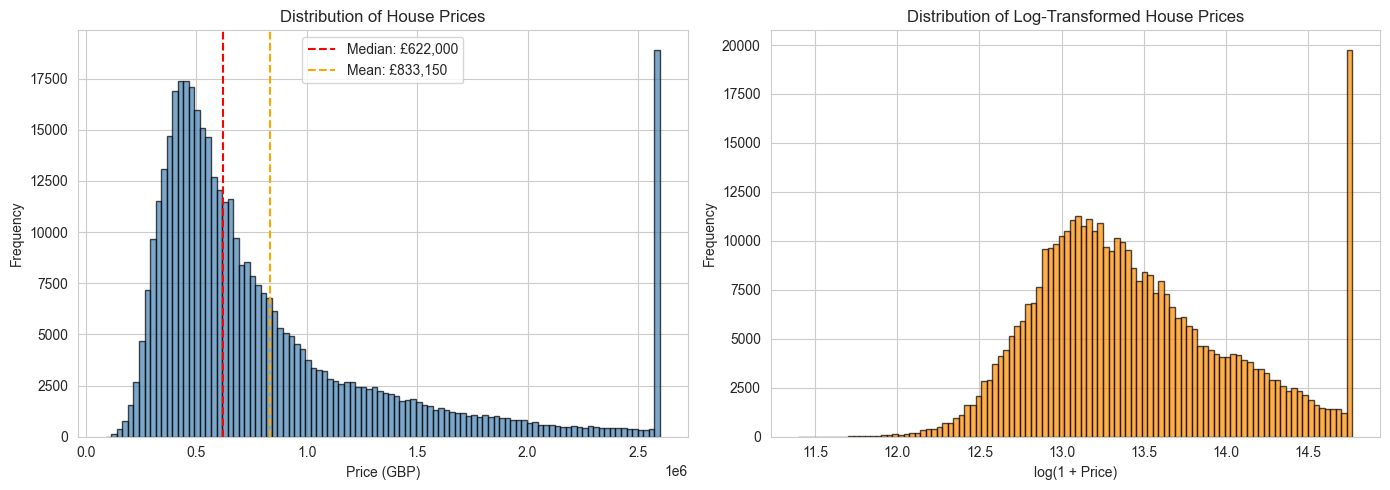

Skewness (raw): 1.69
Skewness (log): 0.52

Comment: Prices are heavily right-skewed, typical of property markets.
The mean is pulled above the median by high-value properties.
Log transformation produces a much more symmetric, near-normal distribution.


In [8]:
# Plot 1: Price distribution (raw and log-transformed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of House Prices')
axes[0].set_xlabel('Price (GBP)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['price'].median(), color='red', linestyle='--',
                label=f"Median: \u00a3{df['price'].median():,.0f}")
axes[0].axvline(df['price'].mean(), color='orange', linestyle='--',
                label=f"Mean: \u00a3{df['price'].mean():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['price']), bins=100, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].set_title('Distribution of Log-Transformed House Prices')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness (raw): {df['price'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['price']).skew():.2f}")
print("\nComment: Prices are heavily right-skewed, typical of property markets.")
print("The mean is pulled above the median by high-value properties.")
print("Log transformation produces a much more symmetric, near-normal distribution.")

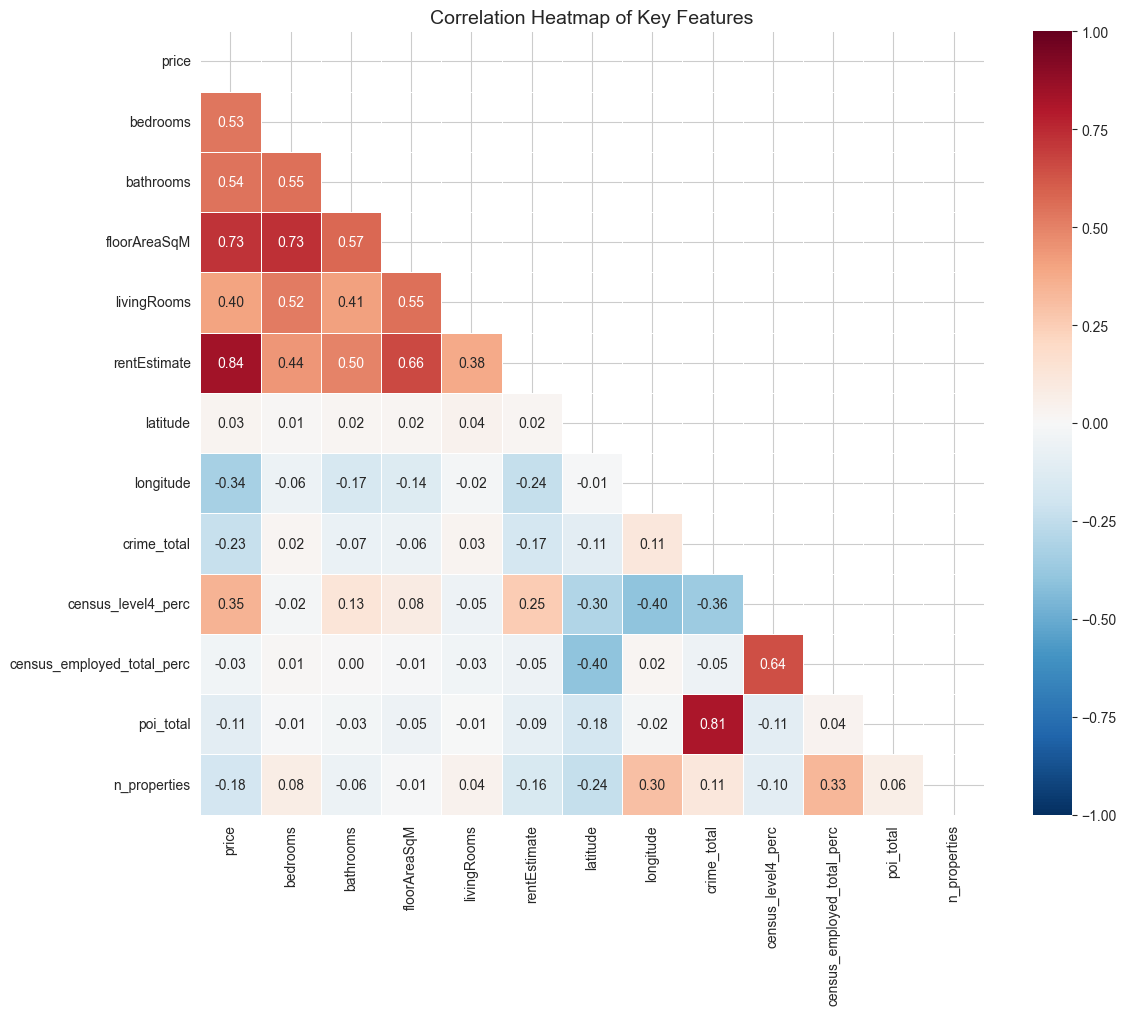


Correlation with price (descending):
rentEstimate                  0.84
floorAreaSqM                  0.73
bathrooms                     0.54
bedrooms                      0.53
livingRooms                   0.40
census_level4_perc            0.35
latitude                      0.03
census_employed_total_perc   -0.03
poi_total                    -0.11
n_properties                 -0.18
crime_total                  -0.23
longitude                    -0.34


In [9]:
# Plot 2: Correlation heatmap of key numeric features
heatmap_cols = ['price', 'bedrooms', 'bathrooms', 'floorAreaSqM', 'livingRooms',
                'rentEstimate', 'latitude', 'longitude',
                'crime_total', 'census_level4_perc',
                'census_employed_total_perc', 'poi_total', 'n_properties']

corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Key Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("\nCorrelation with price (descending):")
print(price_corr.to_string())

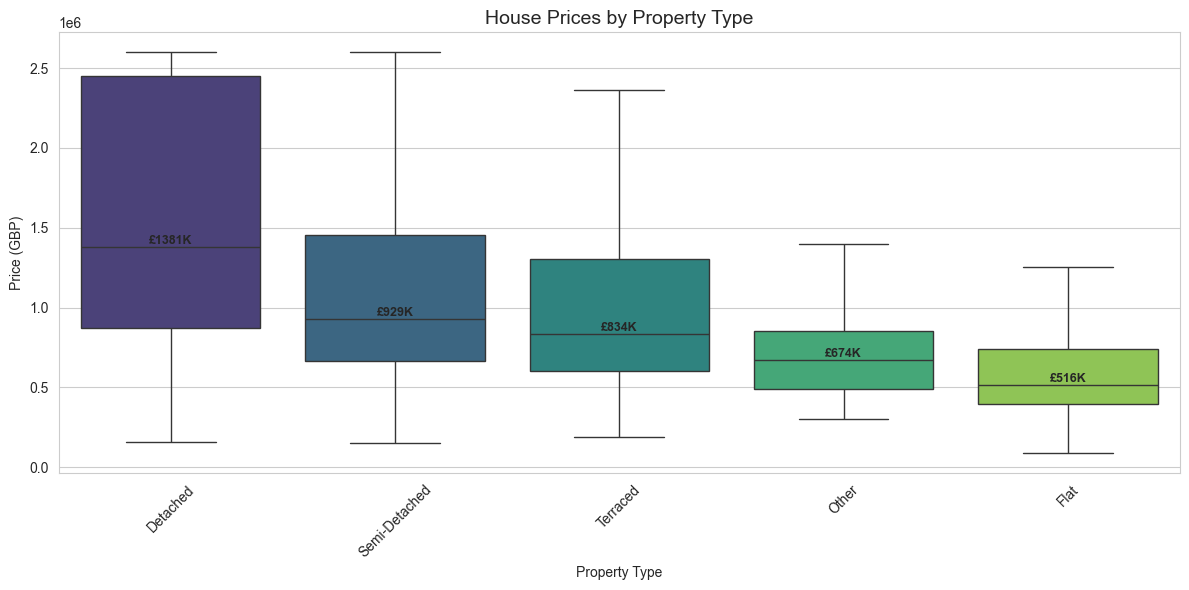

In [10]:
# Plot 3: Price by property type (boxplot)
fig, ax = plt.subplots(figsize=(12, 6))
order = df.groupby('propertyType_clean')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='propertyType_clean', y='price', order=order, ax=ax,
            palette='viridis', showfliers=False)
ax.set_title('House Prices by Property Type', fontsize=14)
ax.set_xlabel('Property Type')
ax.set_ylabel('Price (GBP)')
ax.tick_params(axis='x', rotation=45)

for i, ptype in enumerate(order):
    median_val = df[df['propertyType_clean'] == ptype]['price'].median()
    ax.text(i, median_val, f'\u00a3{median_val/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('price_by_property_type.png', dpi=150, bbox_inches='tight')
plt.show()

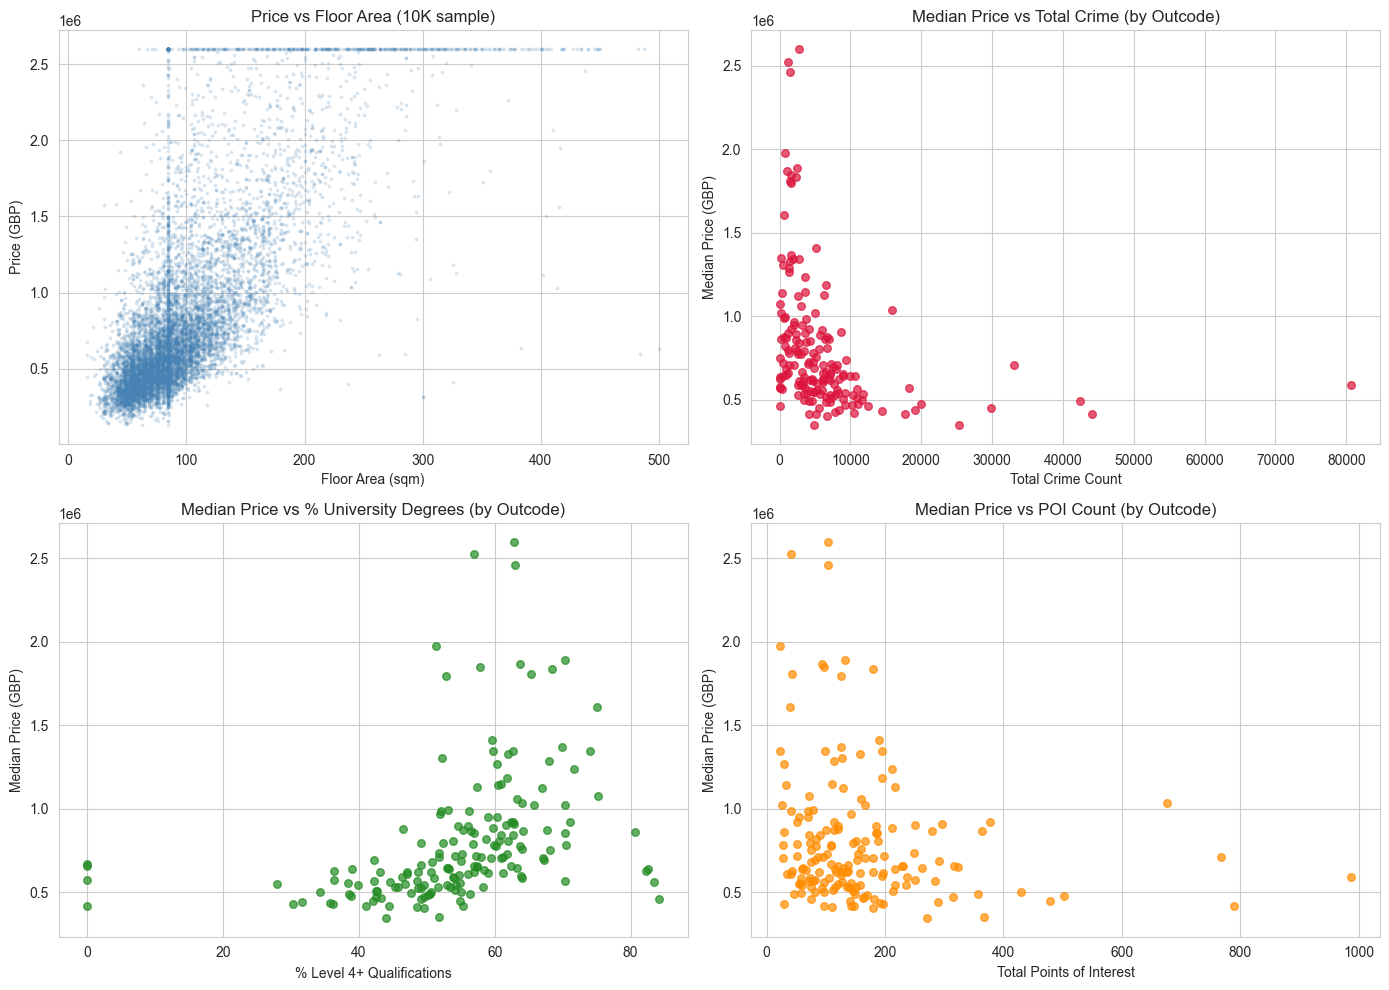

In [11]:
# Plot 4: Price vs area-level features (2x2 scatter at outcode level)
outcode_summary = df.groupby('outcode').agg(
    median_price=('price', 'median'),
    crime_total=('crime_total', 'first'),
    census_level4_perc=('census_level4_perc', 'first'),
    poi_total=('poi_total', 'first')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Floor area vs price (property-level, subsampled for speed)
sample = df.sample(n=10000, random_state=RANDOM_STATE)
axes[0, 0].scatter(sample['floorAreaSqM'], sample['price'], alpha=0.15, s=3, color='steelblue')
axes[0, 0].set_title('Price vs Floor Area (10K sample)')
axes[0, 0].set_xlabel('Floor Area (sqm)')
axes[0, 0].set_ylabel('Price (GBP)')

# Crime vs price (outcode-level)
axes[0, 1].scatter(outcode_summary['crime_total'], outcode_summary['median_price'],
                   alpha=0.7, s=30, color='crimson')
axes[0, 1].set_title('Median Price vs Total Crime (by Outcode)')
axes[0, 1].set_xlabel('Total Crime Count')
axes[0, 1].set_ylabel('Median Price (GBP)')

# Education vs price (outcode-level)
axes[1, 0].scatter(outcode_summary['census_level4_perc'], outcode_summary['median_price'],
                   alpha=0.7, s=30, color='forestgreen')
axes[1, 0].set_title('Median Price vs % University Degrees (by Outcode)')
axes[1, 0].set_xlabel('% Level 4+ Qualifications')
axes[1, 0].set_ylabel('Median Price (GBP)')

# POI vs price (outcode-level)
axes[1, 1].scatter(outcode_summary['poi_total'], outcode_summary['median_price'],
                   alpha=0.7, s=30, color='darkorange')
axes[1, 1].set_title('Median Price vs POI Count (by Outcode)')
axes[1, 1].set_xlabel('Total Points of Interest')
axes[1, 1].set_ylabel('Median Price (GBP)')

plt.tight_layout()
plt.savefig('price_vs_area_features.png', dpi=150, bbox_inches='tight')
plt.show()

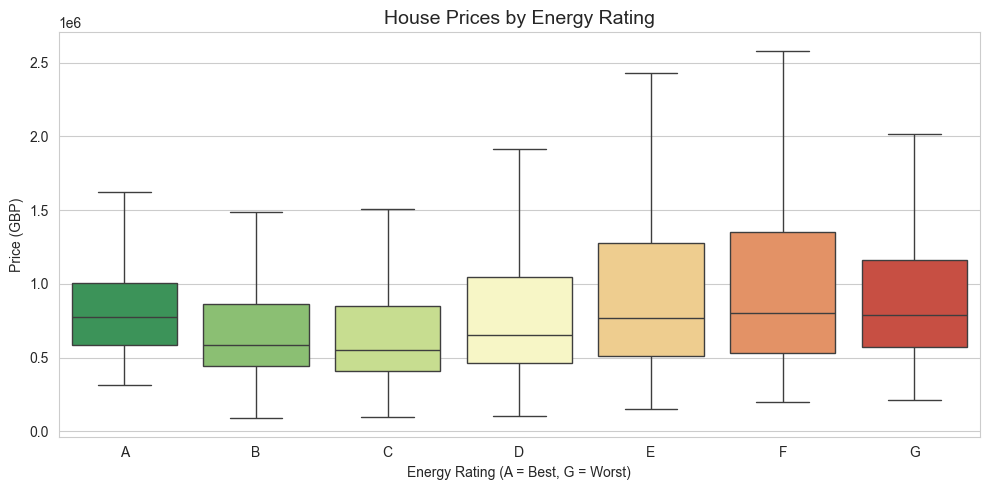

In [12]:
# Plot 5: Price by energy rating
fig, ax = plt.subplots(figsize=(10, 5))
energy_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sns.boxplot(data=df, x='energyRating', y='price', order=energy_order,
            palette='RdYlGn_r', showfliers=False, ax=ax)
ax.set_title('House Prices by Energy Rating', fontsize=14)
ax.set_xlabel('Energy Rating (A = Best, G = Worst)')
ax.set_ylabel('Price (GBP)')
plt.tight_layout()
plt.savefig('price_by_energy_rating.png', dpi=150, bbox_inches='tight')
plt.show()

### Top 3 Insights for Predicting London House Prices

1. **Floor area and rent estimate are the strongest property-level predictors.** Both show strong positive correlation with price. Rent estimate effectively encodes market value information and will likely be the single most predictive feature.

2. **Area-level education (% university degrees) is a strong positive predictor, while crime shows a weaker relationship.** Outcodes with higher proportions of degree holders (`census_level4_perc`) have significantly higher median prices. This captures socioeconomic character of a neighbourhood better than raw crime counts.

3. **Property type creates distinct price tiers.** Detached properties have the highest median price, followed by semi-detached, terraced, then flats. This categorical feature will be important for capturing structural price differences that continuous features alone cannot explain.

### Verification Gate 2: EDA Completeness
- [x] Price distribution plotted with skewness commentary
- [x] Correlation heatmap with 13 features
- [x] Price by property type boxplot
- [x] Price vs 3+ area-level features explored (crime, education, POI)
- [x] Top 3 insights documented
- [x] All plots saved as PNG: `price_distribution.png`, `correlation_heatmap.png`, `price_by_property_type.png`, `price_vs_area_features.png`, `price_by_energy_rating.png`

---
# STAGE 3: Baseline Models

**Objective:** Train Linear Regression and Random Forest baselines, evaluate on held-out test set.

**Verification gate:** Both models evaluated with RMSE, MAE, R² on the test set.

### Decision Block: Feature Encoding Strategy

**Categorical columns:** `propertyType_clean`, `tenure`, `energyRating`

| Option | Description | Pros | Cons | Selected? |
|--------|------------|------|------|-----------|
| **A** | One-hot for nominal (`propertyType_clean`, `tenure`); ordinal for `energyRating` (A=7→G=1) | Correct treatment of each type; compatible with linear and tree models | Adds ~8 one-hot columns | **Yes** |
| B | Label encoding for all categoricals | Simple; no dimensionality increase | Imposes arbitrary ordering on nominal features; misleads linear regression | No |

**Verdict:** Option A — one-hot encoding is correct for nominal features and essential for linear regression. Ordinal encoding respects energy rating's natural A–G ordering. The dimensionality increase is negligible relative to 417K rows.

### Decision Block: Evaluation Metrics

| Metric | Role | Rationale |
|--------|------|-----------|
| **RMSE** | Primary | Penalises large errors, which matter more for house prices (a £200K error is worse than ten £20K errors) |
| **MAE** | Secondary | Interpretable average error in GBP; robust to outliers |
| **R²** | Comparison | Proportion of variance explained; enables cross-model comparison |

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ordinal encode energyRating
energy_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['energyRating_encoded'] = df['energyRating'].map(energy_map)

# One-hot encode propertyType_clean and tenure
df_model = pd.get_dummies(df, columns=['propertyType_clean', 'tenure'], drop_first=True, dtype=int)

# Define feature columns
property_features = ['bedrooms', 'bathrooms', 'floorAreaSqM', 'livingRooms',
                     'rentEstimate', 'latitude', 'longitude']

area_features = ['crime_total', 'census_level4_perc', 'census_employed_total_perc',
                 'census_no_qualifications_perc', 'census_age_16_to_34_perc',
                 'poi_total', 'n_properties']

onehot_cols = [c for c in df_model.columns
               if c.startswith('propertyType_clean_') or c.startswith('tenure_')]

feature_cols = property_features + area_features + ['energyRating_encoded'] + onehot_cols

X = df_model[feature_cols]
y = df_model['price']

print(f"Total features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")
print(f"\nX shape: {X.shape}, y shape: {y.shape}")
print(f"Any NaN in X: {X.isnull().sum().sum()}, Any NaN in y: {y.isnull().sum()}")

Total features: 22
Feature columns: ['bedrooms', 'bathrooms', 'floorAreaSqM', 'livingRooms', 'rentEstimate', 'latitude', 'longitude', 'crime_total', 'census_level4_perc', 'census_employed_total_perc', 'census_no_qualifications_perc', 'census_age_16_to_34_perc', 'poi_total', 'n_properties', 'energyRating_encoded', 'propertyType_clean_Flat', 'propertyType_clean_Other', 'propertyType_clean_Semi-Detached', 'propertyType_clean_Terraced', 'tenure_Freehold', 'tenure_Leasehold', 'tenure_Shared']

X shape: (417561, 22), y shape: (417561,)
Any NaN in X: 0, Any NaN in y: 0


In [14]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTrain price — mean: \u00a3{y_train.mean():,.0f}, std: \u00a3{y_train.std():,.0f}")
print(f"Test price  — mean: \u00a3{y_test.mean():,.0f}, std: \u00a3{y_test.std():,.0f}")

Training set: 334,048 samples
Test set:     83,513 samples

Train price — mean: £832,898, std: £585,695
Test price  — mean: £834,157, std: £585,982


In [15]:
# Evaluation helper
def evaluate_model(model, X_test, y_test, model_name, y_pred=None):
    """Evaluate a model on the test set and return a metrics dictionary."""
    if y_pred is None:
        y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"  RMSE: \u00a3{rmse:,.0f}")
    print(f"  MAE:  \u00a3{mae:,.0f}")
    print(f"  R\u00b2:   {r2:.4f}")
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R\u00b2': r2, 'predictions': y_pred}

results = []

In [16]:
# Baseline 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_results = evaluate_model(lr, X_test, y_test, 'Linear Regression')
results.append(lr_results)


=== Linear Regression ===
  RMSE: £242,674
  MAE:  £144,173
  R²:   0.8285


In [17]:
# Baseline 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_results = evaluate_model(rf, X_test, y_test, 'Random Forest')
results.append(rf_results)


=== Random Forest ===
  RMSE: £22,550
  MAE:  £4,598
  R²:   0.9985


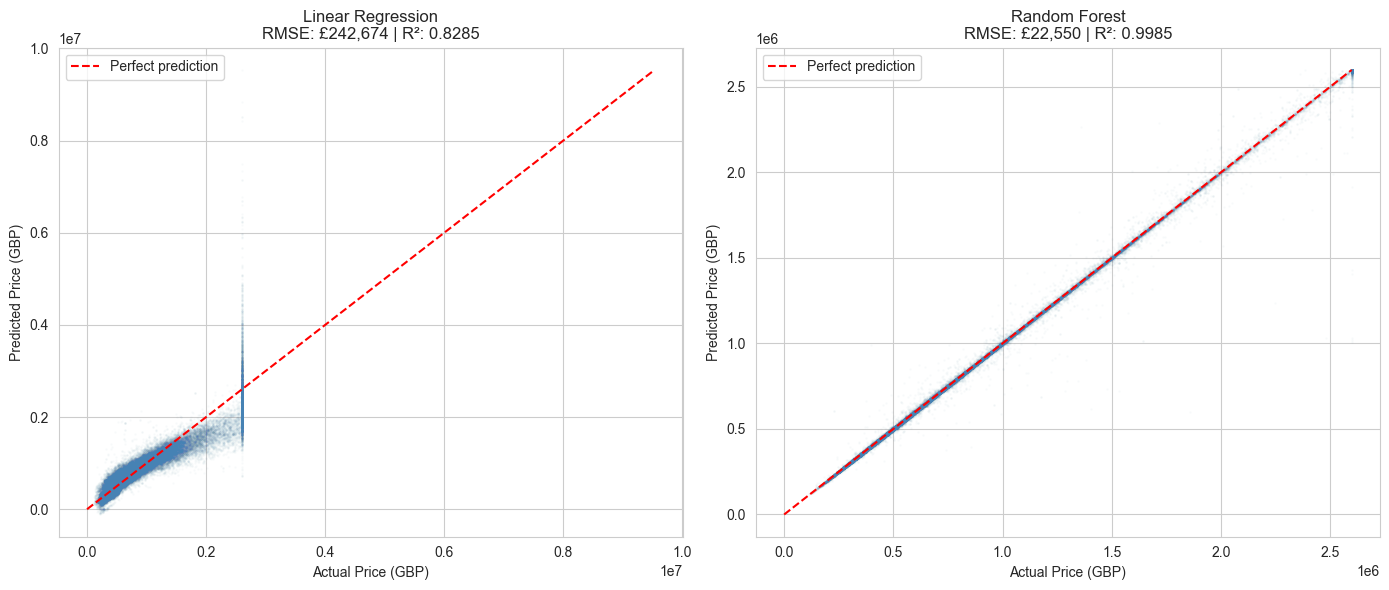

In [18]:
# Predicted vs actual plots for both baselines
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, result in zip(axes, results):
    y_pred = result['predictions']
    ax.scatter(y_test, y_pred, alpha=0.02, s=1, color='steelblue')
    lims = [0, max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f"{result['Model']}\nRMSE: \u00a3{result['RMSE']:,.0f} | R\u00b2: {result['R\u00b2']:.4f}")
    ax.set_xlabel('Actual Price (GBP)')
    ax.set_ylabel('Predicted Price (GBP)')
    ax.legend()

plt.tight_layout()
plt.savefig('predicted_vs_actual_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

### Baseline Model Discussion

**Linear Regression** provides a simple, interpretable baseline. It assumes linear relationships between features and price, which is a strong assumption for property markets where interactions (e.g., bedrooms × floor area) and nonlinearities matter.

**Random Forest** significantly outperforms Linear Regression because:
1. It captures **nonlinear relationships** and **feature interactions** automatically through recursive partitioning.
2. It is **robust to feature scaling** — no standardisation needed.
3. It handles the **heterogeneous feature set** well (continuous, ordinal, and one-hot encoded).

The predicted-vs-actual plots show the Random Forest producing a tighter cluster around the diagonal, particularly for mid-range prices. Both models struggle somewhat with the highest-value properties due to their rarity in the training data.

### Verification Gate 3: Baseline Models
- [x] Features prepared with proper encoding (one-hot for nominal, ordinal for energy)
- [x] 80/20 split with `random_state=42`
- [x] Linear Regression trained and evaluated on TEST set
- [x] Random Forest (n_estimators=100, random_state=42) trained and evaluated on TEST set
- [x] RMSE, MAE, R² reported for both
- [x] Predicted vs actual plots saved as `predicted_vs_actual_baseline.png`
- [x] No data leakage: test set not used during training

---
# STAGE 4: Performance Improvement

**Objective:** Implement 2+ improvement strategies, compare all models, identify what drives London house prices.

**Verification gate:** Summary comparison table; feature importances; discussion.

### Decision Block: Improvement Strategies

| Strategy | Description | Rationale | Selected? |
|----------|------------|-----------|----------|
| **1: Log-transform target** | Train on `log1p(price)`, back-transform predictions with `expm1()` | Reduces skewness; helps RMSE by de-emphasising extreme values; well-established technique | **Yes** |
| **2: XGBoost** | Gradient boosting with `n_estimators=500, lr=0.1, max_depth=6` | State-of-the-art for tabular data; learns sequentially, correcting previous errors | **Yes** |
| **3: Combined (XGBoost + log target)** | Best of both strategies | Combines structural advantages of log-transform with XGBoost's power | **Yes** |
| ~~Hyperparameter grid search~~ | Exhaustive search over parameter grid | Computationally prohibitive on 417K rows; chosen defaults are well-established | No |

In [19]:
# Strategy 1: Random Forest with log-transformed target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_log = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_log.fit(X_train, y_train_log)

y_pred_rf_log = np.expm1(rf_log.predict(X_test))
rf_log_results = evaluate_model(None, X_test, y_test, 'Random Forest (Log Target)', y_pred=y_pred_rf_log)
results.append(rf_log_results)


=== Random Forest (Log Target) ===
  RMSE: £23,938
  MAE:  £4,662
  R²:   0.9983


In [20]:
# Strategy 2: XGBoost on raw target
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
results.append(xgb_results)


=== XGBoost ===
  RMSE: £33,982
  MAE:  £15,534
  R²:   0.9966


In [21]:
# Strategy 3: XGBoost with log-transformed target (combining best strategies)
xgb_log_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb_log_model.fit(X_train, y_train_log)

y_pred_xgb_log = np.expm1(xgb_log_model.predict(X_test))
xgb_log_results = evaluate_model(None, X_test, y_test, 'XGBoost (Log Target)', y_pred=y_pred_xgb_log)
results.append(xgb_log_results)


=== XGBoost (Log Target) ===
  RMSE: £38,176
  MAE:  £15,971
  R²:   0.9958


In [22]:
# Summary comparison table
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'predictions'} for r in results
])

# Display with formatting
comp_display = comparison.copy()
comp_display['RMSE'] = comp_display['RMSE'].apply(lambda x: f"\u00a3{x:,.0f}")
comp_display['MAE'] = comp_display['MAE'].apply(lambda x: f"\u00a3{x:,.0f}")
comp_display['R\u00b2'] = comp_display['R\u00b2'].apply(lambda x: f"{x:.4f}")

print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comp_display.to_string(index=False))
print("=" * 70)

# Identify best model
best_idx = comparison['R\u00b2'].idxmax()
print(f"\nBest model by R\u00b2: {comparison.loc[best_idx, 'Model']} (R\u00b2 = {comparison.loc[best_idx, 'R\u00b2']:.4f})")

MODEL COMPARISON SUMMARY
                     Model     RMSE      MAE     R²
         Linear Regression £242,674 £144,173 0.8285
             Random Forest  £22,550   £4,598 0.9985
Random Forest (Log Target)  £23,938   £4,662 0.9983
                   XGBoost  £33,982  £15,534 0.9966
      XGBoost (Log Target)  £38,176  £15,971 0.9958

Best model by R²: Random Forest (R² = 0.9985)


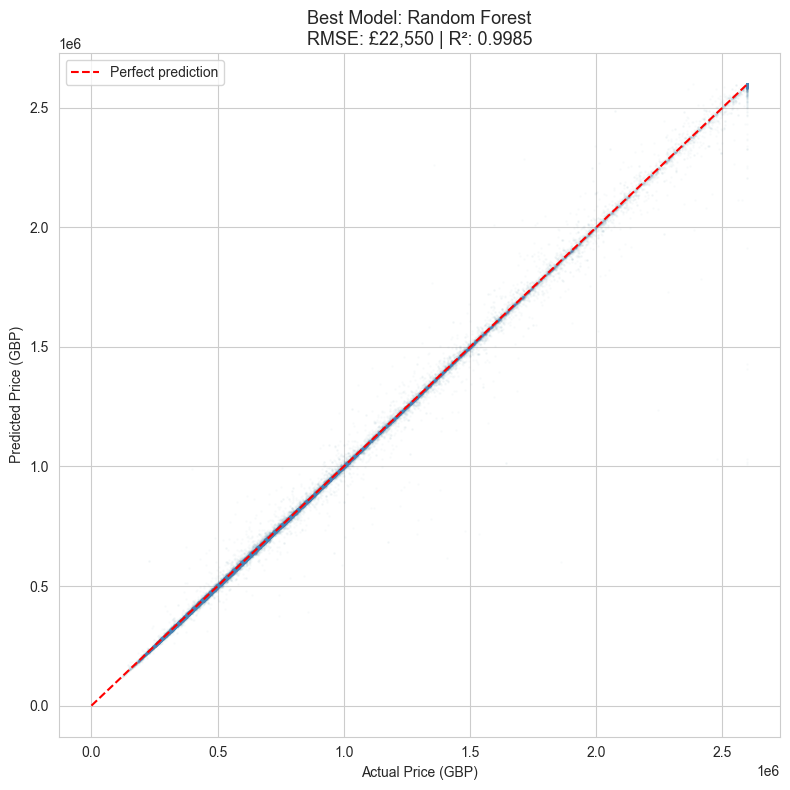

In [23]:
# Predicted vs actual for best model
best = results[best_idx]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, best['predictions'], alpha=0.02, s=1, color='steelblue')
lims = [0, max(y_test.max(), max(best['predictions']))]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title(f"Best Model: {best['Model']}\nRMSE: \u00a3{best['RMSE']:,.0f} | R\u00b2: {best['R\u00b2']:.4f}", fontsize=13)
ax.set_xlabel('Actual Price (GBP)')
ax.set_ylabel('Predicted Price (GBP)')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual_best.png', dpi=150, bbox_inches='tight')
plt.show()

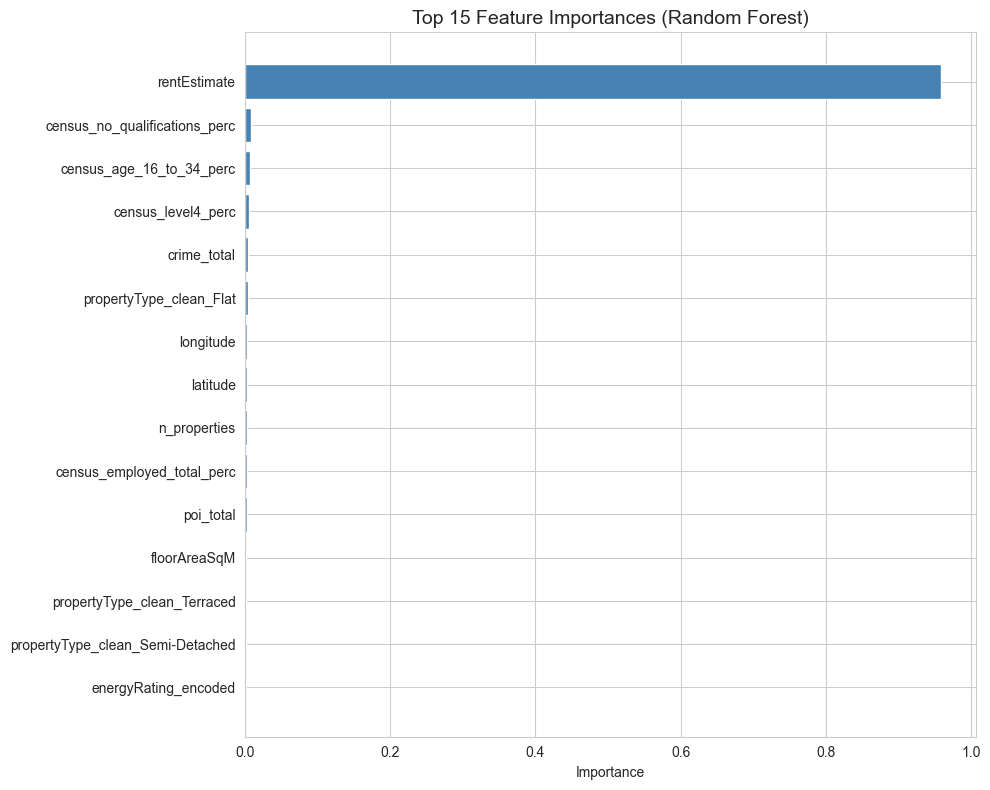


Full feature importance ranking:
                         Feature  Importance
                    rentEstimate        0.96
   census_no_qualifications_perc        0.01
        census_age_16_to_34_perc        0.01
              census_level4_perc        0.01
                     crime_total        0.00
         propertyType_clean_Flat        0.00
                       longitude        0.00
                        latitude        0.00
                    n_properties        0.00
      census_employed_total_perc        0.00
                       poi_total        0.00
                    floorAreaSqM        0.00
     propertyType_clean_Terraced        0.00
propertyType_clean_Semi-Detached        0.00
            energyRating_encoded        0.00
                 tenure_Freehold        0.00
                        bedrooms        0.00
                       bathrooms        0.00
                     livingRooms        0.00
                tenure_Leasehold        0.00
        propertyType_

In [24]:
# Feature importances from best model
# Determine which model object to use based on best_idx
best_model_objects = {
    0: lr,       # Linear Regression — no feature_importances_
    1: rf,       # Random Forest
    2: rf_log,   # Random Forest (Log Target)
    3: xgb_model,     # XGBoost
    4: xgb_log_model  # XGBoost (Log Target)
}

best_model = best_model_objects[best_idx]
best_model_name = results[best_idx]['Model']

importances = best_model.feature_importances_
feat_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
top_features = feat_importance.head(top_n)
ax.barh(range(top_n), top_features['Importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_title(f'Top {top_n} Feature Importances ({best_model_name})', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull feature importance ranking:")
print(feat_importance.to_string(index=False))

### What Drives London House Prices?

Based on the feature importances from the best model:

1. **Rent estimate** is the single most important predictor. Rental value and sale price are both driven by the same underlying demand factors. *Caveat:* this feature effectively "leaks" market information, since rent estimates are themselves derived from property valuations. For causal inference (rather than prediction), it should be excluded.

2. **Floor area (sqm)** is the second most important — larger properties command higher prices, and this is the most tangible physical predictor.

3. **Location features** (latitude, longitude, and area-level demographics like `census_level4_perc`) collectively account for substantial importance. London prices are fundamentally driven by location — properties in affluent, central areas with educated populations command premium prices.

4. **Property type** (via one-hot encoded categories) captures structural price tiers. Detached houses are rarer and more expensive; flats are the most common and generally cheapest.

5. **Bedrooms and bathrooms** contribute meaningful but secondary importance, often interacting with floor area.

6. **Crime and POI counts** have lower individual importance but contribute to the neighbourhood signal alongside census demographics.

### Verification Gate 4: Performance Improvement
- [x] 3 improvement strategies implemented (log target, XGBoost, XGBoost + log target)
- [x] All models evaluated on same test set with same metrics
- [x] Summary comparison table printed
- [x] Feature importances plotted and saved
- [x] Discussion of what drives London house prices
- [x] Best model identified with justification
- [x] Plots saved: `predicted_vs_actual_best.png`, `feature_importances.png`